In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from freeze_thaw.config import config as c
from freeze_thaw.config import StationName
from freeze_thaw.data_preparation.splitting import collect_process_split
from freeze_thaw.modeling.lgb_train import train_model
from freeze_thaw.modeling.lgb_test import lgb_pred
from freeze_thaw.evaluation.statistics import paired_permutation_test

# Model Development

The goal is to train a lightGBM model and determine the optimal set of lagged features, as well as apply statistical tests to determine if using the optimal set of lagged features outperfoms a model trained without lagged features. Models are trained using time series cross-validation on 80% of the data.

---

## Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **Determine Optimal Lag Configuration**
3. **Lagged Features vs No Lagged Features**
    - *3.1 Training and Evaluation*
    - *3.2 Train Results*
    - *3.3 Difference in Scores*
4. **Statistical Analysis**

---

## 1. Setup

### 1.1 Variables

In [2]:
lags_test = [1, 2, 3, 4, 5, 7, 10, 15, 20, 30]
label_map = {
    c.CLASSES[0]: 0,
    c.CLASSES[1]: 1,
    c.CLASSES[2]: 2,
}
train_size = 0.8
n_splits = 5

### 1.2 Functions

In [3]:
def pipeline(stations: type[StationName],
             label_map: dict[str, int],
             n_splits: int,
             train_size: float,
             lagged_features: bool = False,
             lags: list[int] | None = None) -> (pd.DataFrame, pd.DataFrame):
    """
    Train lgbm models for all stations using time series cross-validation then predict on test, with results
    for the train and test sets collected in separate dfs. The train results are for the out-of-fold (OOF) predictions.
    :param stations: StationName class from config.py
    :param label_map: mapping of c.CLASSES to int labels
    :param n_splits: number of folds for cross-validation
    :param train_size: decimal fraction size of training data
    :param lagged_features: create lagged features or not
    :param lags: list of lags e.g. [1, 3] will create features for the backscatter from one and three datapoints prior
    :return: result_train_df and result_test_df
    """
    result_train_df = pd.DataFrame(columns=["Station", "OOF Macro F1", "OOF Transition F1"])
    result_test_df = pd.DataFrame(columns=["Station", "Macro F1", "Transition F1"])

    for station in stations:
        print(f"    Station: {station}")
        train, test = collect_process_split(station,
                                            c.CLEANED_DATA_PATH,
                                            c.DATETIMEINDEX_NAME,
                                            c.ISMN_LONG_VAR_NAME,
                                            c.ASCAT_KEY_COLS,
                                            c.ERA5_KEY_COLS,
                                            train_size,
                                            label_map,
                                            lagged_features,
                                            lags)

        # train and evaluate model
        train_result = train_model(train, n_splits, label_map)

        # log train results
        result_train_df.loc[len(result_train_df)] = [station, train_result.oof_macro_f1, train_result.oof_transition_f1]

        # predict on test
        test_result = lgb_pred(test, model=train_result.model, label_encoding=label_map)

        # log test results
        result_test_df.loc[len(result_test_df)] = [station, test_result.macro_f1, test_result.transition_f1]

    return result_train_df, result_test_df

def optimal_lag_config_pipeline(stations: type[StationName],
                                label_map: dict[str, int],
                                n_splits: int,
                                train_size: float,
                                lags: list[int]) -> pd.DataFrame:
    """
    Trains lgbm models for all stations and lag configurations using time series cross-validation. For example, if given
    lags=[1, 2, 3], it will train three models for each set of stations with the following lags: [1], [1, 2], and [1, 2, 3].
    :param stations: StationName class from config.py
    :param label_map: mapping of c.CLASSES to int labels
    :param n_splits: number of folds for cross-validation
    :param train_size: decimal fraction size of training data
    :param lags: list of lags
    :return: average OOF metrics for all stations for each lag configuration as a pd.DataFrame. For example,
    given lags=[1, 2, 3], the df will contain three records.
    """
    # average OOF F1 is for all stations for one set of lags i.e. 10 stations results in one score.
    result_df = pd.DataFrame(columns=["Max Lag", "Average OOF Macro F1", "Average OOF Transition F1"])

    for i in range(len(lags)):
        subset = lags[0:i+1]
        max_lag = lags[i]
        print(f"Lag configuration: {subset}")

        intermediate_results = pd.DataFrame(columns=["OOF Macro F1", "OOF Transition F1"])
        for station in stations:
            print(f"    Station: {station}")
            train, _ = collect_process_split(station,
                                                c.CLEANED_DATA_PATH,
                                                c.DATETIMEINDEX_NAME,
                                                c.ISMN_LONG_VAR_NAME,
                                                c.ASCAT_KEY_COLS,
                                                c.ERA5_KEY_COLS,
                                                train_size,
                                                label_map,
                                                True,
                                                subset)

            # train and evaluate model
            train_result = train_model(train, n_splits, label_map)

            # log train results
            intermediate_results.loc[len(intermediate_results)] = [train_result.oof_macro_f1, train_result.oof_transition_f1]

        result_df.loc[i] = [max_lag, intermediate_results["OOF Macro F1"].mean(), intermediate_results["OOF Transition F1"].mean()]

    return result_df

## 2. Determine Optimal Lag Configuration

In [4]:
lag_config_results = optimal_lag_config_pipeline(StationName, label_map, n_splits, train_size, lags_test)

Lag configuration: [1]
    Station: Aberdeen-35-WNW
    Station: Jamestown-38-WSW
    Station: GobblersKnob
    Station: Nenana
    Station: L23
    Station: L38
    Station: NST-07
    Station: NST-09
    Station: SOD012
    Station: SOD103
Lag configuration: [1, 2]
    Station: Aberdeen-35-WNW
    Station: Jamestown-38-WSW
    Station: GobblersKnob
    Station: Nenana
    Station: L23
    Station: L38
    Station: NST-07
    Station: NST-09
    Station: SOD012
    Station: SOD103
Lag configuration: [1, 2, 3]
    Station: Aberdeen-35-WNW
    Station: Jamestown-38-WSW
    Station: GobblersKnob
    Station: Nenana
    Station: L23
    Station: L38
    Station: NST-07
    Station: NST-09
    Station: SOD012
    Station: SOD103
Lag configuration: [1, 2, 3, 4]
    Station: Aberdeen-35-WNW
    Station: Jamestown-38-WSW
    Station: GobblersKnob
    Station: Nenana
    Station: L23
    Station: L38
    Station: NST-07
    Station: NST-09
    Station: SOD012
    Station: SOD103
Lag configurat

In [5]:
lag_config_results

,Max Lag,Average OOF Macro F1,Average OOF Transition F1
0,1.0,0.764541,0.630677
1,2.0,0.765752,0.634104
2,3.0,0.765306,0.633194
3,4.0,0.764785,0.631233
4,5.0,0.764047,0.629225
5,7.0,0.763412,0.628379
6,10.0,0.764626,0.630425
7,15.0,0.765133,0.629715
8,20.0,0.767236,0.628036
9,30.0,0.763803,0.624111


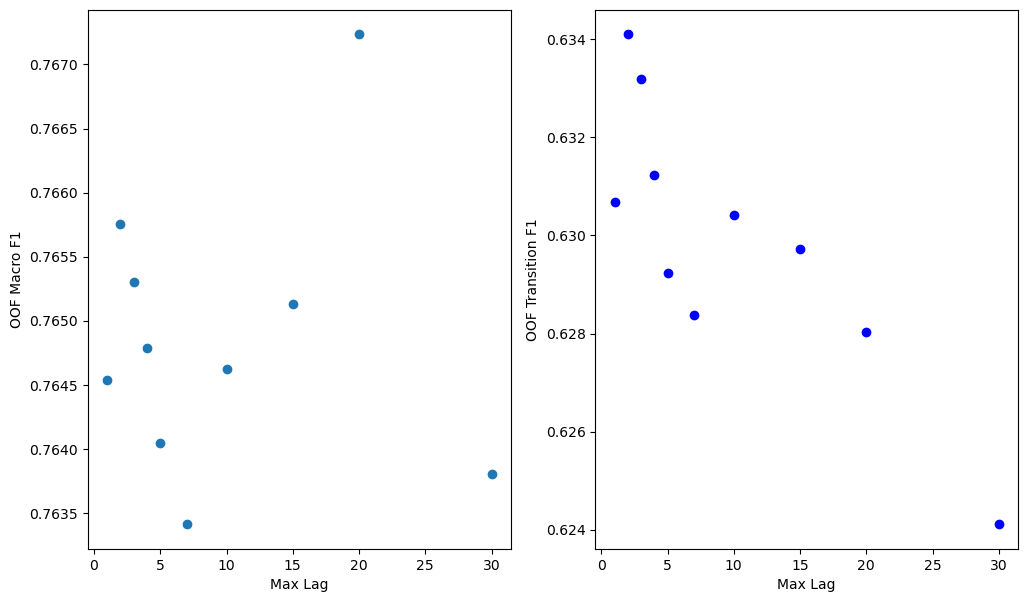

In [6]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 7),
)

ax1.scatter(lag_config_results["Max Lag"], lag_config_results["Average OOF Macro F1"])
ax1.set_ylabel("OOF Macro F1")
ax1.set_xlabel("Max Lag")

ax2.scatter(lag_config_results["Max Lag"], lag_config_results["Average OOF Transition F1"], c="b", label="Average Transition F1")
ax2.set_ylabel("OOF Transition F1")
ax2.set_xlabel("Max Lag")

plt.show()

The cross-validated results suggest that increasing temporal history does not uniformly improve classification performance. Macro F1 exhibits a shallow optimum at approximately 20 lags, whereas transition F1 is maximized using a much shorter history of two lags. Since identifying the transition state is more important, a lag configuration of [1, 2] will be selected.

In [4]:
lags_optimal = [1, 2]

## 3. Lagged Features vs No Lagged Features

### 3.1 Training and Evaluation

#### No lagged features

In [5]:
result_unlagged_train_df, _ = pipeline(StationName, label_map, n_splits, train_size)

    Station: Aberdeen-35-WNW
    Station: Jamestown-38-WSW
    Station: GobblersKnob
    Station: Nenana
    Station: L23
    Station: L38
    Station: NST-07
    Station: NST-09
    Station: SOD012
    Station: SOD103


#### Lagged features

In [6]:
result_lagged_train_df, _ = pipeline(StationName, label_map, n_splits, train_size, True, lags_optimal)

    Station: Aberdeen-35-WNW
    Station: Jamestown-38-WSW
    Station: GobblersKnob
    Station: Nenana
    Station: L23
    Station: L38
    Station: NST-07
    Station: NST-09
    Station: SOD012
    Station: SOD103


### 3.2 Train Results

No Lagged features

In [7]:
result_unlagged_train_df

,Station,OOF Macro F1,OOF Transition F1
0,Aberdeen-35-WNW,0.675337,0.495772
1,Jamestown-38-WSW,0.706799,0.499065
2,GobblersKnob,0.830895,0.615858
3,Nenana,0.779494,0.546943
4,L23,0.886870,0.746348
5,L38,0.804115,0.547771
6,NST-07,0.858307,0.714715
7,NST-09,0.821871,0.605487
8,SOD012,0.721542,0.703579
9,SOD103,0.586165,0.847539


Lagged features

In [8]:
result_lagged_train_df

,Station,OOF Macro F1,OOF Transition F1
0,Aberdeen-35-WNW,0.664652,0.492460
1,Jamestown-38-WSW,0.690365,0.486111
2,GobblersKnob,0.837320,0.631674
3,Nenana,0.798642,0.598207
4,L23,0.876506,0.720109
5,L38,0.802377,0.542208
6,NST-07,0.847888,0.690402
7,NST-09,0.822983,0.605364
8,SOD012,0.729081,0.719391
9,SOD103,0.587708,0.855115


### 3.3 Difference in Scores

Show the scores for lagged - unlagged, with positive scores indicating better performance with lagged features.

In [9]:
train_diff = result_lagged_train_df.copy()
float_cols = ["OOF Macro F1", "OOF Transition F1"]
train_diff[float_cols] = result_lagged_train_df[float_cols] - result_unlagged_train_df[float_cols]
train_diff = train_diff.rename(columns={
    "Macro F1": "Macro F1 Difference",
    "Transition F1": "Transition F1 Difference",
})

train_diff

,Station,OOF Macro F1,OOF Transition F1
0,Aberdeen-35-WNW,-0.010686,-0.003312
1,Jamestown-38-WSW,-0.016435,-0.012954
2,GobblersKnob,0.006424,0.015816
3,Nenana,0.019148,0.051264
4,L23,-0.010365,-0.026239
5,L38,-0.001737,-0.005563
6,NST-07,-0.010420,-0.024312
7,NST-09,0.001111,-0.000123
8,SOD012,0.007540,0.015812
9,SOD103,0.001544,0.007576


## 4. Statistical Analysis

Perform a paired sign-flipping permutation test to determine if using `lags=[1,2]` results in a statistically meaningful improvement ($\alpha=0.05$) in model performance compared to not using lagged features.

$H_0: F1_{lagged} = F1_{unlagged}$

$H_1: F1_{lagged} > F1_{unlagged}$

### Macro F1

In [10]:
observed_macro_f1, p_value_macro_f1 = paired_permutation_test(result_unlagged_train_df["OOF Macro F1"],
                                                              result_lagged_train_df["OOF Macro F1"],
                                                              alternative="greater")

print(f"Observed mean difference: {observed_macro_f1:6f}")
print(f"p-value: {p_value_macro_f1:4f}")

Observed mean difference: -0.001387
p-value: 0.671875


### Transition F1

In [11]:
observed_transition_f1, p_value_transition_f1 = paired_permutation_test(result_unlagged_train_df["OOF Transition F1"],
                                                                        result_lagged_train_df["OOF Transition F1"],
                                                                        alternative="greater")

print(f"Observed mean difference: {observed_transition_f1:6f}")
print(f"p-value: {p_value_transition_f1:4f}")

Observed mean difference: 0.001796
p-value: 0.415039


The statistical analysis does not support the hypothesis that using the optimal lag configuration results in better model performance compared to using unlagged features.